In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qm import SimulationConfig
from qm.qua import *
import os
import xarray as xr
import json
from quam_libs.components import QuAM
from quam_libs.lib.save_utils import find_numbered_folder

2025-10-24 11:11:49,459 - qm - INFO     - Starting session: 83a19832-65bc-4a2b-b231-d666bc99ecbc


c:\Users\willi\Downloads\Texbooks Fall-2025\QOLAB\qolab-start\.venv\Lib\site-packages\qm\results\__init__.py:15: DeprecationWarning: qm.results is deprecated since "1.2.3" and will be removed in "1.3.0". If you need anything from this module, import it directly from `qm` or from `qm.simulate` for simulator-related functionality.
  warnings.warn(


In [2]:
def load_dataset(serial_number, target_filename = "ds", parameters = None):
    """
    Loads a dataset from a file based on the serial number.
    
    Args:
        serial_number: The serial number to search for.
        base_folder: The base directory to search in.
    
    Returns:
        An xarray Dataset if found, None otherwise.
    """
    if not isinstance(serial_number, int):
        raise ValueError("serial_number must be an integer")
        
    base_folder = find_numbered_folder("data",serial_number)
    # Look for .nc files in the subfolder
    nc_files = [f for f in os.listdir(base_folder) if f.endswith('.h5')]
    
    # look for filename.h5
    is_present = target_filename in [file.split('.')[0] for file in nc_files]
    filename = [file for file in nc_files if target_filename == file.split('.')[0]][0] if is_present else None
    json_filename = "data.json"
    
    if nc_files:
        # Assuming there's only one .nc file per folder
        file_path = os.path.join(base_folder, filename)
        json_path = os.path.join(base_folder, json_filename)
        # Open the dataset
        ds = xr.open_dataset(file_path)
        with open(json_path, 'r') as f:
            json_data = json.load(f)
        try:
            machine = QuAM.load(base_folder + "/quam_state/state.json")
        except Exception as e:
            print(f"Error loading machine: {e}")
            machine = None
        qubits = [machine.qubits[qname] for qname in ds.qubit.values]    
        if parameters is not None:
            for param_name, param_value in parameters:
                if param_name != "load_data_id":
                    if param_name in json_data["initial_parameters"]:
                        setattr(parameters, param_name, json_data["initial_parameters"][param_name])
            return ds, machine, json_data, qubits,parameters
        else:
            return ds, machine, json_data, qubits
    else:
        print(f"No .nc file found in folder: {base_folder}")
        return None


# Load Old Data
To load old data, we use the `load_dataset` command with the serial number of the dataset. The serial number is the number of the experiment in the `data` tab of the `qualibrate` dashboard; also, it is the numbers coming directly after the `#` in the `data` sub-folders.

Here are the relevant experiments we will look at in this assignment:
- 65: Experiment number 65 was the 'bad' data we took in class for IQ Blobs on 2025-10-13;
- 71: Experiment number 71 was the 'good' data I showed in class for IQ Blobs (taken on 2025-10-14); 
- 58: Experiment number 58 was the 'bad' data we took in class for T1 on 2025-10-13; 
- 70: Experiment number 70 was the 'good' data I showed in class for T1 (taken on 2025-10-14).

Other experiments are provided in the data folder for you to peruse. The qolab-start provided data analysis can be applied to old data, even without a token, by navigating to the associated node in node library and putting in the data ID in the `Load Data ID` field. For example, experiment 54 was qubit spectroscopy (see `data/2025-10-13/#54_03a_Qubit_Spectroscopy_153559/`). Navigating to the node library, node `03a_Qubit_Spectroscopy` and putting in experiment 54 into `Load Data ID` will allow you to run the analysis on the old data (reproducing the plot that is already in the data tab for experiment 54). This will be useful when we make want to make new nodes that operate on the same experimental data. Note that all of the nodes are defined in `code/calibration_graph/`. New nodes can be added here; old nodes can adjusted. It can also be helpful to look there to see how the fits are currently done. This might help you with the below assignment.

I provide two example dataset loading and plotting to help for the problems.

In [3]:
b = load_dataset(65)

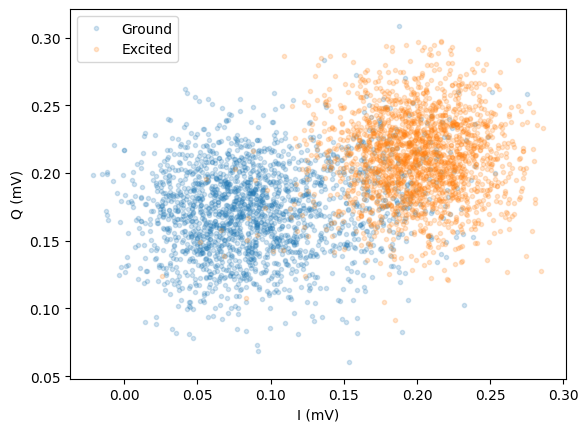

In [4]:
plt.plot(1e3*b[0].I_g.sel(qubit="q2").values,1e3*b[0].Q_g.sel(qubit="q2"),".",alpha=0.2,label="Ground")
plt.plot(1e3*b[0].I_e.sel(qubit="q2").values,1e3*b[0].Q_e.sel(qubit="q2"),".",alpha=0.2,label="Excited")
plt.xlabel("I (mV)")
plt.ylabel("Q (mV)")
plt.legend()

In [5]:
a = load_dataset(70)

The data is in a `xarray`, which has a lot of nifty features. For now, we can access the raw data via directly accessing the `values`. 

In [6]:
print("Qubit 2's averaged populations.")
#Note that qubit 2 is index 1!
print(a[0]['state'].values[1])

Qubit 2's averaged populations.
[0.994 0.952 0.924 0.87  0.87  0.854 0.81  0.78  0.744 0.712 0.628 0.676
 0.624 0.616 0.598 0.558 0.512 0.512 0.496 0.486 0.446 0.386 0.398 0.384
 0.354 0.372 0.368 0.358 0.34  0.286 0.274 0.256 0.236 0.232 0.23  0.242
 0.254 0.206 0.18  0.216 0.222 0.202 0.164 0.13  0.17  0.174 0.17  0.14
 0.17  0.138 0.126 0.102 0.132 0.128 0.118 0.126 0.116 0.088 0.106 0.126
 0.082 0.086 0.086 0.09  0.098 0.074 0.1   0.088 0.08  0.086 0.072 0.074
 0.066 0.084 0.112 0.076 0.076 0.088 0.08  0.076]


We can plot the data versus time for qubit 2 using

Text(0, 0.5, 'State')

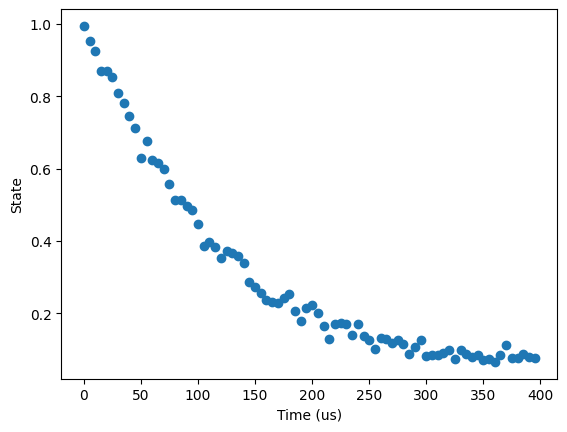

In [7]:
plt.clf()
plt.plot(a[0]["idle_time"],a[0]['state'].values[1],"o")
plt.xlabel("Time (us)")
plt.ylabel("State")

## Problem #2
Plot the data for the IQ Blobs experiments in datasets 65 and 71. Using `two_state_discriminator` (`from qualang_tools.analysis.discriminator import two_state_discriminator`) find a threshold between `0` and `1` and calculate the confusion matrix. Compare the confusion matrices from experiments 65 and 71. `code/calibration_graph/07c_IQ_Blobs.py` may be helpful here. Plot all IQ blobs and confusion matrices for both experiments. Which qubit, from any experiment, performs the best?



        Fidelity Matrix:
        -----------------
        | 0.865 | 0.136 |
        ----------------
        | 0.042 | 0.958 |
        -----------------
        IQ plane rotated by: 339.6°
        Threshold: 2.052e-01
        Fidelity: 91.1%
        


(5.927691165928979, 0.20524110037837323, 91.125, 0.8645, 0.1355, 0.042, 0.958)

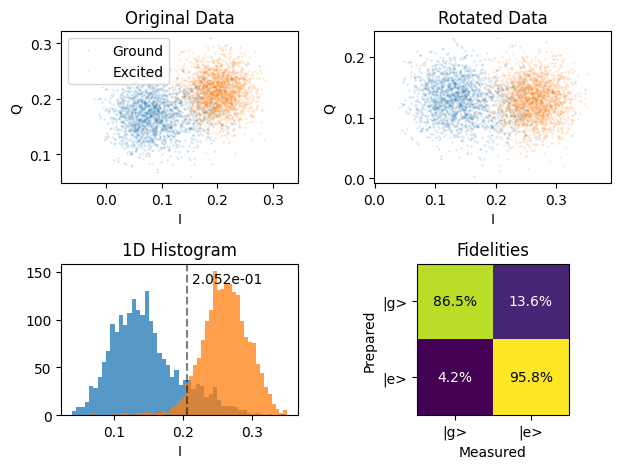

In [8]:
from qualang_tools.analysis.discriminator import two_state_discriminator

data = load_dataset(65)
two_state_discriminator(1e3*data[0].I_g.sel(qubit="q2").values, 1e3*data[0].Q_g.sel(qubit="q2").values,
                        1e3*data[0].I_e.sel(qubit="q2").values, 1e3*data[0].Q_e.sel(qubit="q2").values)


        Fidelity Matrix:
        -----------------
        | 0.958 | 0.043 |
        ----------------
        | 0.021 | 0.979 |
        -----------------
        IQ plane rotated by: 2.9°
        Threshold: 1.783e-01
        Fidelity: 96.8%
        


(0.05108717996224721,
 0.17828267378665852,
 96.825,
 0.9575,
 0.0425,
 0.021,
 0.979)

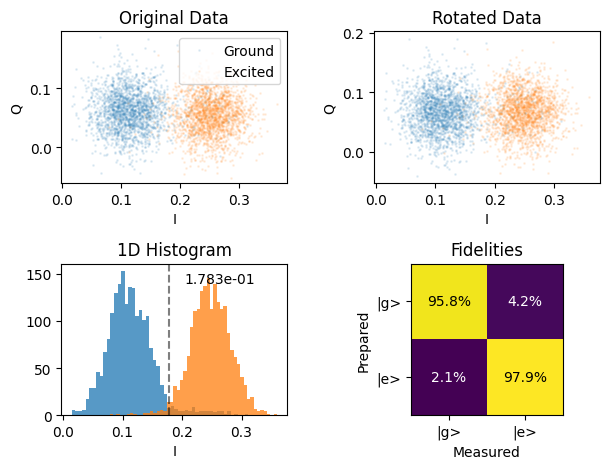

In [9]:
data = load_dataset(71)
two_state_discriminator(1e3*data[0].I_g.sel(qubit="q2").values, 1e3*data[0].Q_g.sel(qubit="q2").values,
                        1e3*data[0].I_e.sel(qubit="q2").values, 1e3*data[0].Q_e.sel(qubit="q2").values)

The threshold for the qubit in experiment

## Problem #3
Plot the data for the T1 experiments in datasets 58 and 70. Fit the T1 times for each 'working' qubit using the raw data, as accessed above. Compare the T1s from dataset 58 and dataset 70. You can accomplish this by fitting an exponential decay using, for example, `curve_fit` from `scipy.optimize`. `local_packages/quam_libs/quam_libs/lib/fit.py` gives the example used in `qolab-start`. Compare the T1 times for both experiments. Plot all the T1 plots for both experiments. Which qubit, from any experiment, performs the best?

-4.202429790610486e-27 1.0000000105826903


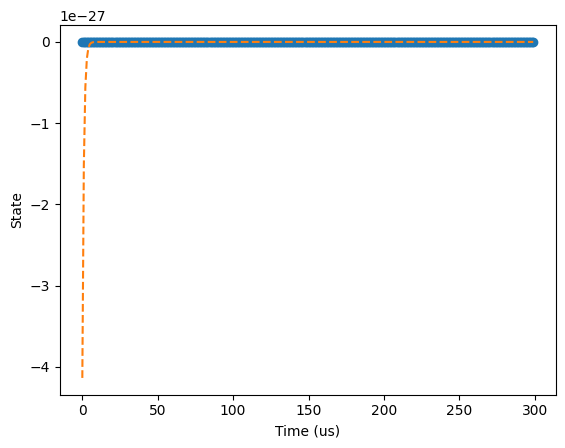

In [53]:
from scipy.optimize import curve_fit

data = load_dataset(58)

def test_func(x, a, b):
    return a * np.exp(-1 * b * x)
(a, b) = curve_fit(test_func, data[0]["idle_time"], data[0]['state'].values[1])[0]
print(a, b)
fit = a * np.exp(-1 * b * data[0]["idle_time"])

plt.plot(data[0]["idle_time"], data[0]['state'].values[1], "o")
plt.plot(data[0]["idle_time"], fit, "--")
plt.xlabel("Time (us)")
plt.ylabel("State")
plt.show()

c:\Users\willi\Downloads\Texbooks Fall-2025\QOLAB\qolab-start\.venv\Lib\site-packages\xarray\computation\apply_ufunc.py:814: RuntimeWarning: overflow encountered in exp
  result_data = func(*input_data)


1.005238629526949 0.008033010056449743


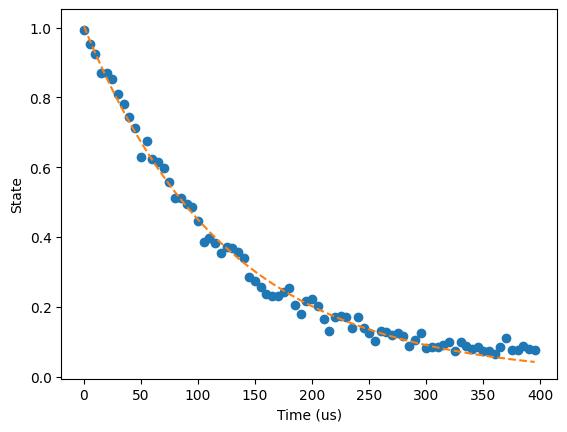

In [34]:
data = load_dataset(70)

def test_func(x, a, b):
    return a * np.exp(-1 * b * x)
(a, b) = curve_fit(test_func, data[0]["idle_time"], data[0]['state'].values[1])[0]
print(a, b)
fit = a * np.exp(-1 * b * data[0]["idle_time"])

plt.plot(data[0]["idle_time"], data[0]['state'].values[1], "o")
plt.plot(data[0]["idle_time"], fit, "--")
plt.xlabel("Time (us)")
plt.ylabel("State")
plt.show()

## Problem #4

Between the experiments run on 2025/10/13 and 2025/10/14, there was a large change in performance. This can be attributed to the tune-up of the qubits between 10-13 and 10-14. All of the attributes that go into this are in the state.json file. Compare the `data/2025-10-13/#58_05_T1_160134/quam_state/state.json` and `data/2025-10-14/#70_05_T1_091936/quam_state/state.json` files. What are the most significant changes between the two? How, in terms of Hamiltonians, resonators, input/output theory, IQ Blobs, or any other concept we have learned, would that have had an impact?